<a href="https://colab.research.google.com/github/kduran-stack/wildfire_cost_prediction/blob/main/wildfire_cost_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data-driven investment portfolio example for companies that will help reduce the cost of California wildfires.

# By Kyla Duran | This work is a combination of human written and AI-assisted data modeling.  

In [ ]:
#Goal: Using machine learning to predict future costs of wildfires and exporting the results to excel

#datasets

import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import kagglehub
import os
!pip install zenodo-get
#downloads the entire record using its record ID.
!zenodo_get -r 14712845



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.2/254.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.0 MB/s eta 0:00:00
INFO: Output directory: /content
INFO: Title: California Weather and Fire Prediction Dataset (1984–2025) with Engineered Features
INFO: Total size: 1.5 MB
INFO: Number of files: 1
SUCCESS: All specified files have been processed.


In [ ]:
#loading in data

#dataset from Vivek Attri https://www.kaggle.com/datasets/vivekattri/california-wildfire-damage-2014-feb2025

#dataset info 2014-(feb)2025: Analyzing Property Loss, Financial Impact, and Causes Over the Past Decade.

path = kagglehub.dataset_download("vivekattri/california-wildfire-damage-2014-feb2025")
df = pd.read_csv(f"{path}/California Wildfire Damage.csv")
print("Path to dataset files:", path)
df = pd.read_csv(f"{path}/California Wildfire Damage.csv")


df.tail()
#note df is not organized by date


100%|██████████| 2.96k/2.96k [00:00<00:00, 2.20MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/vivekattri/california-wildfire-damage-2014-feb2025/versions/1


,Incident_ID,Date,Location,Area_Burned (Acres),Homes_Destroyed,Businesses_Destroyed,Vehicles_Damaged,Injuries,Fatalities,Estimated_Financial_Loss (Million $),Cause
95,INC1095,2018-01-16,Mendocino County,13112,1468,46,281,89,17,4008.58,Human Activity
96,INC1096,2022-07-07,Shasta County,39209,710,282,189,34,14,376.72,Human Activity
97,INC1097,2016-05-18,Shasta County,11863,702,9,40,100,1,1474.78,Human Activity
98,INC1098,2014-06-24,Napa Valley,1338,1619,262,293,94,3,3308.74,Human Activity
99,INC1099,2021-03-20,Mendocino County,44299,1217,172,176,81,20,4276.78,Human Activity


In [ ]:
# Zenedo file
#citation: Yavas, C. E., Kadlec, C., kim, J., & Chen, L. (2025). California Weather and Fire Prediction Dataset (1984–2025) with Engineered Features [Data set]. Zenodo. https://doi.org/10.5281/zenodo.14712845
#https://zenodo.org/records/14712845
df2 = pd.read_csv('CA_Weather_Fire_Dataset_1984-2025.csv')
df2.tail()

#end date is 1/12/2025




,DATE,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR
14983,2025-01-08,0.0,73.0,53.0,10.51,False,2025,20.0,0.143973,1,Winter,0.0,6.485714,8
14984,2025-01-09,0.0,68.0,46.0,4.92,False,2025,22.0,0.072353,1,Winter,0.0,6.550000,9
14985,2025-01-10,0.0,70.0,46.0,3.58,False,2025,24.0,0.051143,1,Winter,0.0,6.327143,10
14986,2025-01-11,0.0,66.0,46.0,NaN,False,2025,20.0,NaN,1,Winter,0.0,6.561667,11
14987,2025-01-12,0.0,69.0,46.0,NaN,False,2025,23.0,NaN,1,Winter,0.0,7.068000,12


In [ ]:
#converting both datasets to be the same time

#note to self: notes on parameters in google doc notes

# Use 'mixed' to handle inconsistent date/time strings automatically
df['date'] = pd.to_datetime(df['Date'], format='mixed', errors='coerce')
df2['date'] = pd.to_datetime(df2['DATE'], format='mixed', errors='coerce')

#only matching on the day (removes hours/minutes)
df['date'] = df['date'].dt.normalize()
df2['date'] = df2['date'].dt.normalize()

# merge now that both 'date' columns are standardized
df_combined = pd.merge(df, df2, on='date', how='left')

#sorting by date and resetting indexes
#date sort
df_combined = df_combined.sort_values(by='date', ascending=True)
#index reset
df_combined = df_combined.reset_index(drop=True)
df_combined.head() #end date is 2023/12/08


,Incident_ID,Date,Location,Area_Burned (Acres),Homes_Destroyed,Businesses_Destroyed,Vehicles_Damaged,Injuries,Fatalities,Estimated_Financial_Loss (Million $),...,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR
0,INC1058,2014-02-03,Santa Barbara County,47674,1186,438,71,54,11,2580.87,...,8.72,False,2014,14.0,0.145333,2,Winter,0.09,7.765714,34
1,INC1074,2014-03-04,Napa Valley,9737,1735,386,52,44,10,4075.67,...,5.82,False,2014,11.0,0.089538,3,Spring,2.91,7.445714,63
2,INC1038,2014-03-16,Mendocino County,41647,484,210,180,7,16,286.64,...,5.59,False,2014,27.0,0.067349,3,Spring,0.00,5.494286,75
3,INC1061,2014-03-28,Los Angeles County,11162,544,223,196,100,8,85.57,...,7.61,False,2014,14.0,0.113582,3,Spring,0.01,9.202857,87
4,INC1017,2014-04-16,Sonoma County,25094,1014,288,269,30,12,268.91,...,6.93,False,2014,9.0,0.103433,4,Spring,0.00,7.347143,106


# Financial/Invest Analysis
# 1. Risk Identification

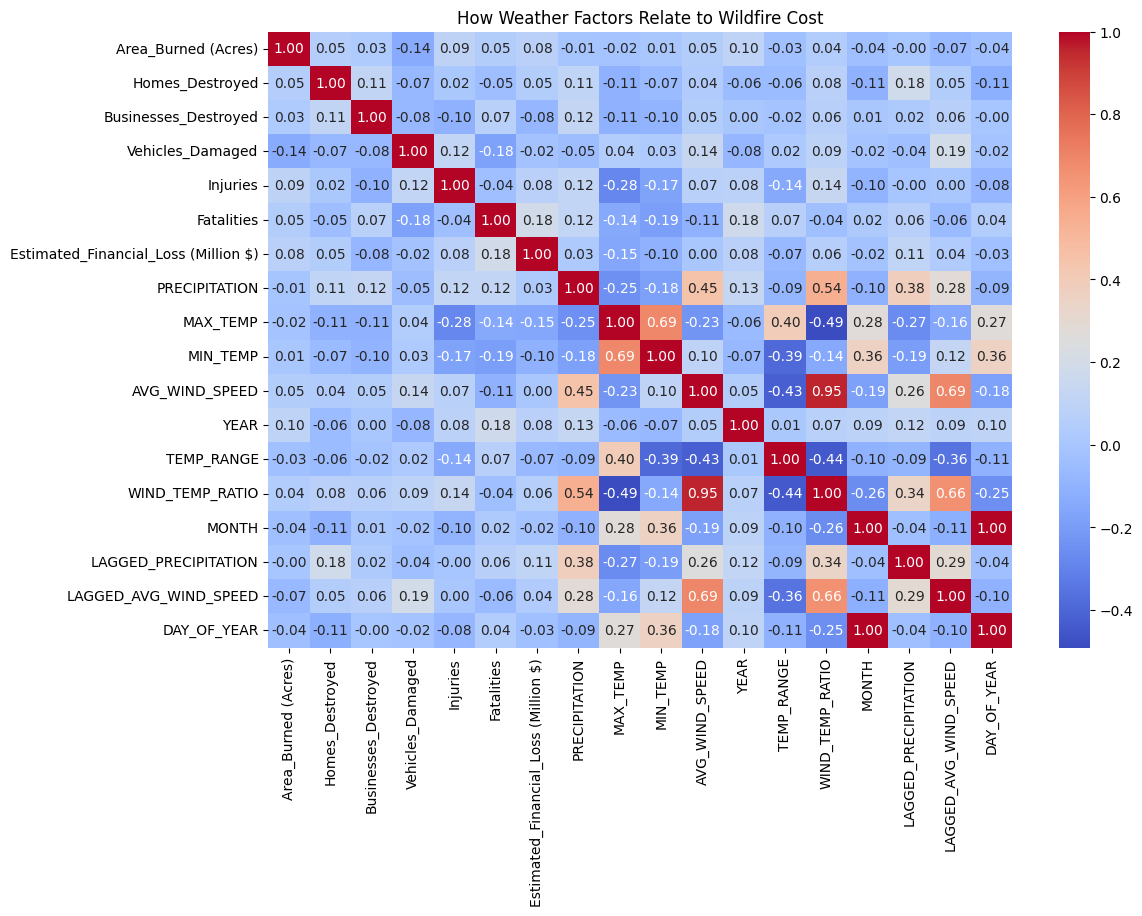

Incident_ID                             0
Date                                    0
Location                                0
Area_Burned (Acres)                     0
Homes_Destroyed                         0
Businesses_Destroyed                    0
Vehicles_Damaged                        0
Injuries                                0
Fatalities                              0
Estimated_Financial_Loss (Million $)    0
Cause                                   0
date                                    0
DATE                                    0
PRECIPITATION                           0
MAX_TEMP                                0
MIN_TEMP                                0
AVG_WIND_SPEED                          0
FIRE_START_DAY                          0
YEAR                                    0
TEMP_RANGE                              0
WIND_TEMP_RATIO                         0
MONTH                                   0
SEASON                                  0
LAGGED_PRECIPITATION              

In [ ]:
#code suggestions come back later

#correlation heatmap
import seaborn as sns


#simple sns.heatmap(df)
corr_matrix = df_combined.select_dtypes(include=['number']).corr()

# heatmap: finding correlations between variables
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("How Weather Factors Relate to Wildfire Cost")
plt.show()

#pick  x values that actually matter
#checking for missing data
print(df_combined.isnull().sum())

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

features = ['MAX_TEMP', 'AVG_WIND_SPEED', 'LAGGED_PRECIPITATION', 'WIND_TEMP_RATIO']
X = df_combined[features]
y = df_combined['Estimated_Financial_Loss (Million $)']

split_point = int(len(df_combined) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

#training
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

#predictions
predictions = model.predict(X_test)



Key insights from the correlation map:

**Acreage and Damage**: There is a surprisingly low correlation (0.08) between Area_Burned and Estimated_Financial_Loss. This suggests that fire size alone is a poor predictor of economic impact.

**Primary Cost Drivers**: The strongest predictors of loss are Homes_Destroyed (0.18) and Injuries (0.12), indicating that financial risk is concentrated in the Wildland-Urban Interface (WUI).

**Investment Implications**: From a Private Equity perspective, the data suggests that startups focusing on Home Hardening and Structure Protection offer higher "avoided cost" returns than those focused solely on general suppression.

This data underscores the systemic risk to land and real estate valuations in fire-prone regions, where unpriced wildfire exposure can lead to sudden asset devaluation and increased insurance volatility.

# 2. Investment: Example of Portfolio Synergy Graph

Potential companies to invest in based off the Machine Learning correlation map.

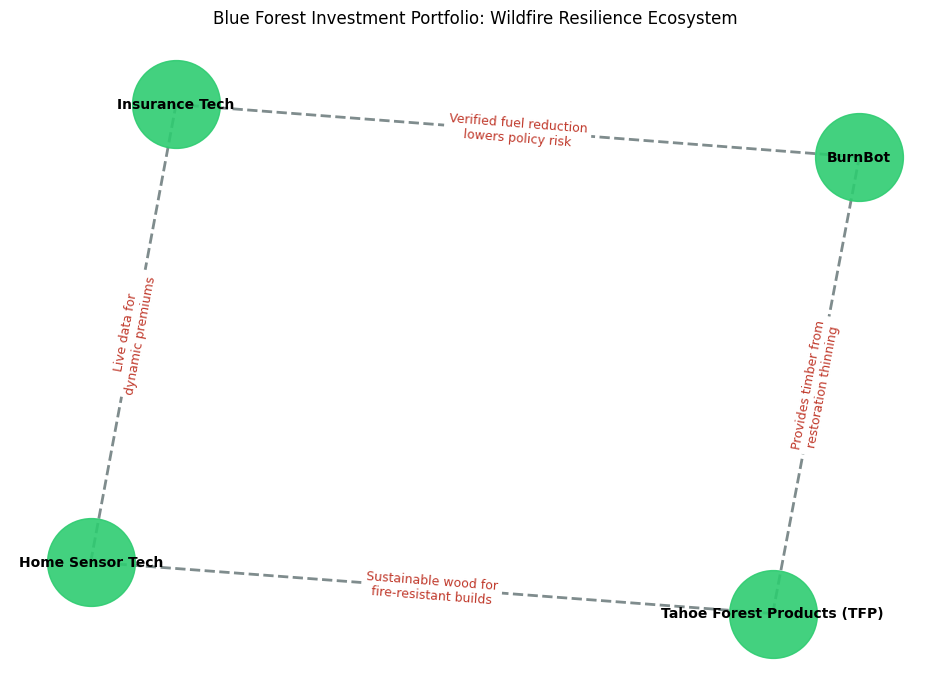

In [ ]:
import networkx as nx

companies = [
    "Tahoe Forest Products (TFP)",
    "BurnBot",
    "Home Sensor Tech",
    "Insurance Tech"
]

synergies = [
    ("BurnBot", "Tahoe Forest Products (TFP)", "Provides timber from\nrestoration thinning"),
    ("Home Sensor Tech", "Insurance Tech", "Live data for\ndynamic premiums"),
    ("BurnBot", "Insurance Tech", "Verified fuel reduction\nlowers policy risk"),
    ("Tahoe Forest Products (TFP)", "Home Sensor Tech", "Sustainable wood for\nfire-resistant builds")
]

#graph
G = nx.Graph()
G.add_nodes_from(companies)

for company_a, company_b, relation in synergies:
    G.add_edge(company_a, company_b, label=relation)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=4000, node_color="#2ecc71", alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")
nx.draw_networkx_edges(G, pos, width=2, edge_color="#7f8c8d", style="dashed")

#labels
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='#c0392b', font_size=9)

plt.title("Blue Forest Investment Portfolio: Wildfire Resilience Ecosystem", pad=20)
plt.axis('off')
plt.show()


# Identifying Limited Partners

# 3. Predictive Models

In this section, I build predictive models informed by wildfire and climate research to project future wildfire costs. These models combine historical data with scenario-based assumptions to explore how changing environmental conditions could impact long-term financial outcomes.

    Year  Projected_Cost
0   2025     1012.230000
1   2026     1021.087013
2   2027     1030.021524
3   2028     1039.034212
4   2029     1048.125762
5   2030     1057.296862
6   2031     1066.548210
7   2032     1075.880506
8   2033     1085.294461
9   2034     1094.790787
10  2035     1104.370207
11  2036     1114.033446
12  2037     1123.781239
13  2038     1133.614324
14  2039     1143.533450
15  2040     1153.539368
16  2041     1163.632837
17  2042     1173.814624
18  2043     1184.085502
19  2044     1194.446250
20  2045     1204.897655
21  2046     1215.440510
22  2047     1226.075614
23  2048     1236.803776
24  2049     1247.625809
25  2050     1258.542535


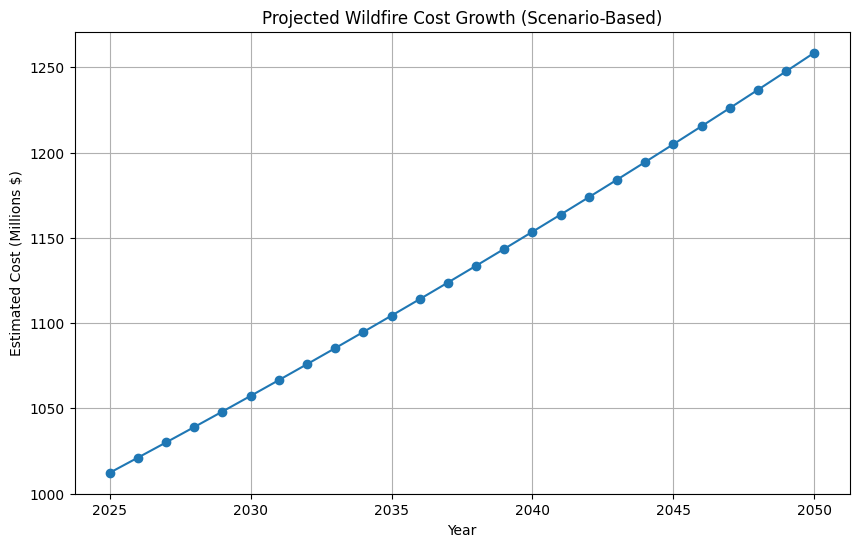

In [ ]:
"""  The following is based off this research paper:
Westerling, A.L., Bryant, B.P., Preisler, H.K. et al. Climate change and growth
scenarios for California wildfire. Climatic Change 109 (Suppl 1), 445–463 (2011).
https://doi.org/10.1007/s10584-011-0329-9
"""

initial_cost = df_combined['Estimated_Financial_Loss (Million $)'].iloc[-1]

#Models from the paper predicted median increases in wildfires to be 21% - 23%
# Using the lowend 21%:
# 21%/26 years

# annual growth rate (0.875%)
growth_rate = 0.00875

years = np.arange(2025, 2051)
projected_costs = [initial_cost]

for i in range(1, len(years)):
    next_value = projected_costs[-1] * (1 + growth_rate)
    projected_costs.append(next_value)

df_projection = pd.DataFrame({
    'Year': years,
    'Projected_Cost': projected_costs
})

print(df_projection)
plt.figure(figsize=(10,6))
plt.plot(df_projection['Year'], df_projection['Projected_Cost'], marker='o')
plt.title("Projected Wildfire Cost Growth (Scenario-Based)")
plt.xlabel("Year")
plt.ylabel("Estimated Cost (Millions $)")
plt.grid(True)
plt.show()

As climate change accelerates, wildfire frequency and severity are outpacing historical risk models, leading to record-breaking financial losses—most recently evidenced by the $135 billion in damage from the 2025 Los Angeles fires. For **insurance and real estate companies**, these rising costs are no longer just operational expenses; they are systemic threats to insurability and property value. By participating as **Limited Partners** in a resilience-focused portfolio, these entities move from reactive loss-coverage to proactive risk-mitigation, investing directly in the technologies that protect their own balance sheets

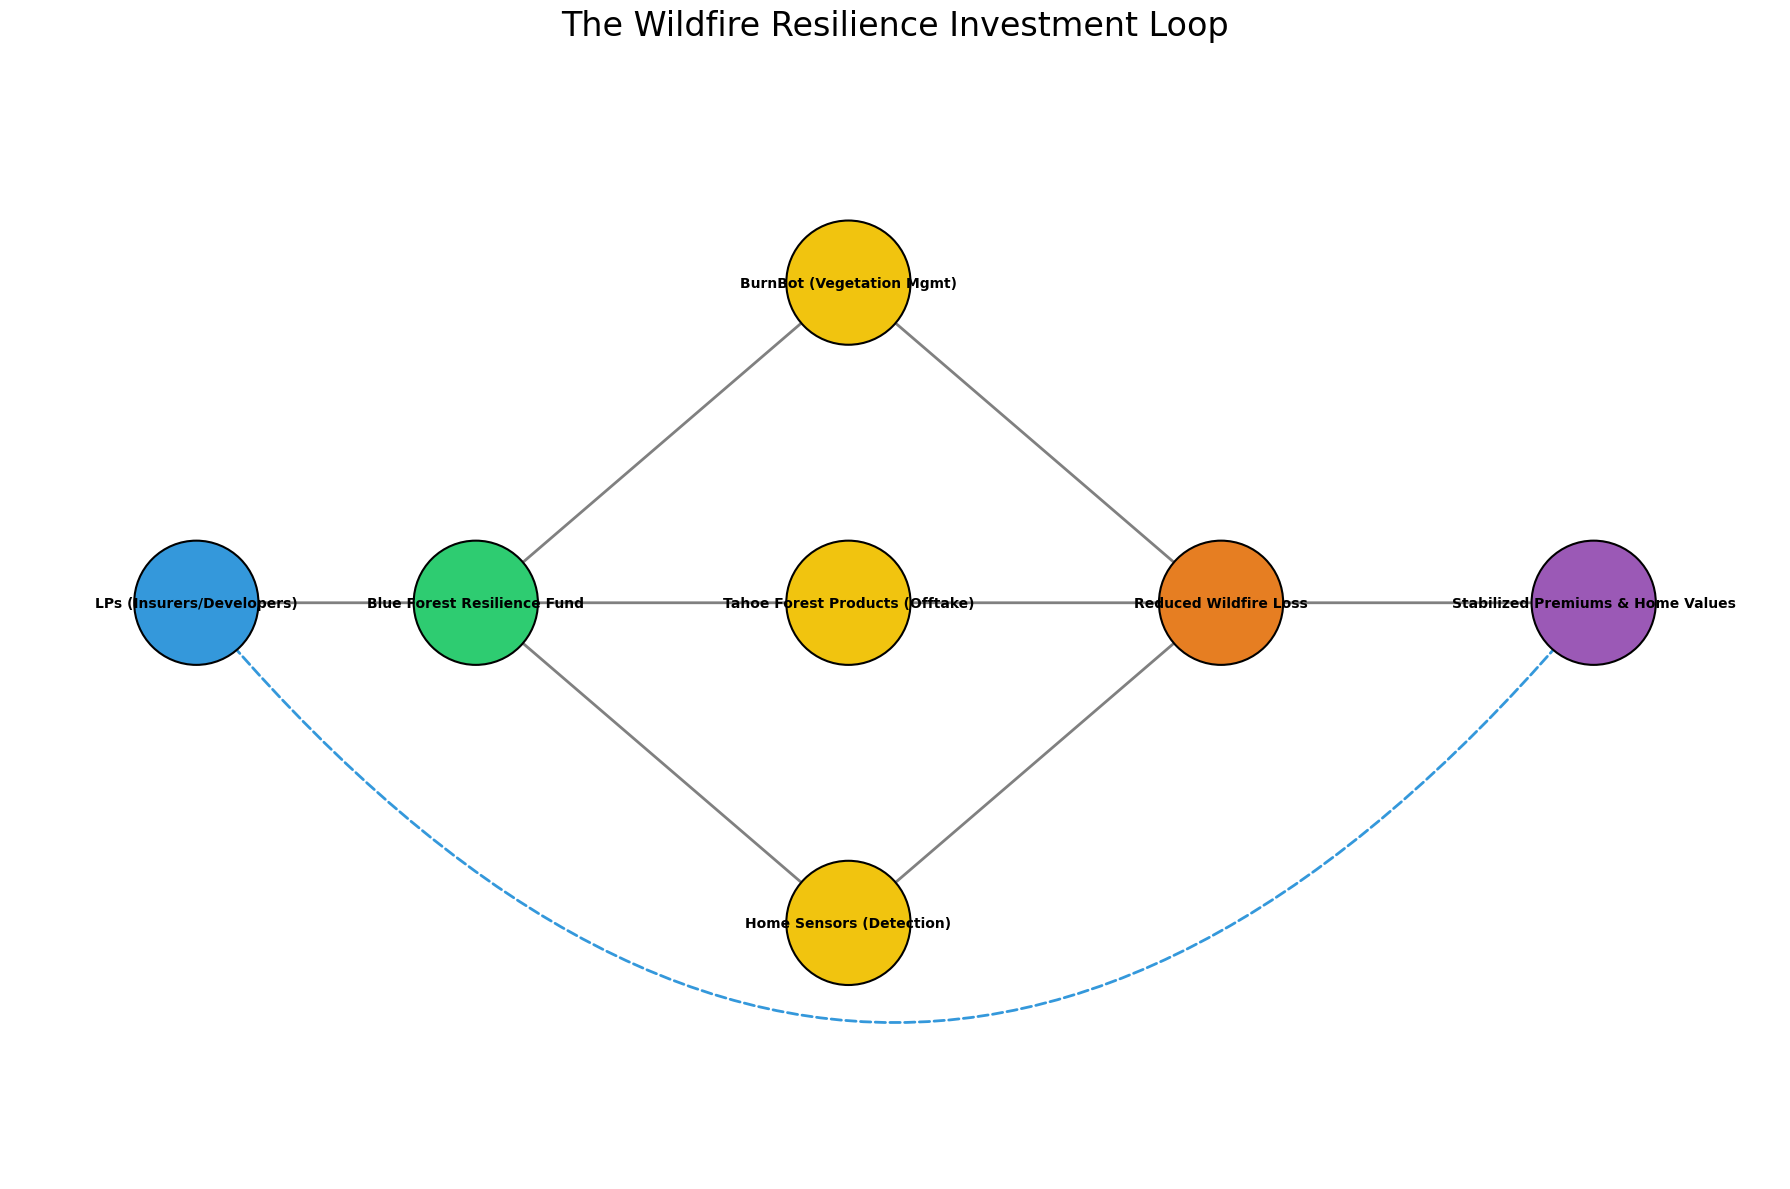

In [21]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph()

#nodes and colors
nodes_info = {
    "LPs (Insurers/Developers)": "#3498db",
    "Blue Forest Resilience Fund": "#2ecc71",
    "BurnBot (Vegetation Mgmt)": "#f1c40f",
    "Tahoe Forest Products (Offtake)": "#f1c40f",
    "Home Sensors (Detection)": "#f1c40f",
    "Reduced Wildfire Loss": "#e67e22",
    "Stabilized Premiums & Home Values": "#9b59b6"
}

G.add_nodes_from(nodes_info.keys())

pos = {
    "LPs (Insurers/Developers)":          (0, 0),
    "Blue Forest Resilience Fund":        (1.5, 0),

    "BurnBot (Vegetation Mgmt)":          (3.5, 2.5),
    "Tahoe Forest Products (Offtake)":    (3.5, 0),
    "Home Sensors (Detection)":           (3.5, -2.5),

    "Reduced Wildfire Loss":              (5.5, 0),
    "Stabilized Premiums & Home Values":  (7.5, 0)
}

edges = [
    ("LPs (Insurers/Developers)", "Blue Forest Resilience Fund"),
    ("Blue Forest Resilience Fund", "BurnBot (Vegetation Mgmt)"),
    ("Blue Forest Resilience Fund", "Tahoe Forest Products (Offtake)"),
    ("Blue Forest Resilience Fund", "Home Sensors (Detection)"),
    ("BurnBot (Vegetation Mgmt)", "Reduced Wildfire Loss"),
    ("Tahoe Forest Products (Offtake)", "Reduced Wildfire Loss"),
    ("Home Sensors (Detection)", "Reduced Wildfire Loss"),
    ("Reduced Wildfire Loss", "Stabilized Premiums & Home Values"),
    ("Stabilized Premiums & Home Values", "LPs (Insurers/Developers)")
]
G.add_edges_from(edges)

fig, ax = plt.subplots(figsize=(18, 12))
node_colors = [nodes_info[node] for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=8000, node_color=node_colors,
                       edgecolors="black", linewidths=1.5, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold", ax=ax)
regular_edges = edges[:-1]
nx.draw_networkx_edges(G, pos, edgelist=regular_edges, edge_color="gray",
                       arrowsize=25, width=2, ax=ax)

nx.draw_networkx_edges(G, pos, edgelist=[edges[-1]], edge_color="#3498db",
                       arrowsize=25, width=2, style="dashed",
                       connectionstyle="arc3,rad=-0.6", ax=ax)

#size of grapg
ax.set_xlim(-1, 8.5)
ax.set_ylim(-4.5, 4.0)

ax.set_title("The Wildfire Resilience Investment Loop", fontsize=24, pad=40)
ax.axis('off')

plt.tight_layout()
plt.show()
